# Stage-A — исходное обучение USER-BGE

Публичный переносимый notebook без раскрытия абсолютных путей сервера.

`deepvk/USER-bge-m3` → `matches_llm.parquet` → `best.pt` → Stage-B → soup → symmetry TTA.

- preprocessing: frozen v1, attr cap 520
- component split seed: 13
- train seed: 42
- epochs: 2
- confidence-weighted BCE + swap augmentation

In [ ]:
import json, os, platform, subprocess, sys
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow
import pyarrow.parquet as pq
import sklearn
import torch, transformers

START = Path.cwd().resolve()
TRAIN_SCRIPT = Path(os.getenv("BGE_TRAIN_SCRIPT", "train_user_bge_m3_320.py")).expanduser()
if not TRAIN_SCRIPT.is_absolute():
    candidates = [START / TRAIN_SCRIPT, *[p / TRAIN_SCRIPT for p in START.parents]]
    TRAIN_SCRIPT = next((p for p in candidates if p.exists()), candidates[0])
TRAIN_SCRIPT = TRAIN_SCRIPT.resolve()
PROJECT_DIR = TRAIN_SCRIPT.parent
DATA_DIR = Path(os.getenv("BGE_DATA_DIR", PROJECT_DIR)).expanduser().resolve()
OUTPUT_ROOT = Path(os.getenv("BGE_OUTPUT_ROOT", START / "output")).expanduser().resolve()
assert TRAIN_SCRIPT.exists(), "Укажите BGE_TRAIN_SCRIPT"
masked = lambda path: f"***/{Path(path).name}"

# Версии зафиксированы по исходному notebook-окружению user_bge_m3_320_run.
EXPECTED_VERSIONS = {
    "python": "3.12",
    "torch": "2.6.0+cu124",
    "transformers": "4.57.6",
    "numpy": "2.2.6",
    "pandas": "2.3.3",
    "pyarrow": "23.0.1",
    "scikit-learn": "1.8.0",
}
ACTUAL_VERSIONS = {
    "python": ".".join(map(str, sys.version_info[:2])),
    "torch": torch.__version__,
    "transformers": transformers.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "pyarrow": pyarrow.__version__,
    "scikit-learn": sklearn.__version__,
}
assert ACTUAL_VERSIONS == EXPECTED_VERSIONS, (
    f"Версии окружения отличаются от poetry.lock: {ACTUAL_VERSIONS}"
)

print("train script:", masked(TRAIN_SCRIPT))
print("data dir: *** | output root: ***")
print("environment: locked and verified")

rows = []
for name in ["items.parquet", "matches_llm.parquet"]:
    path = DATA_DIR / name
    assert path.exists(), f"Нет входного файла: ***/{name}"
    rows.append({"file": f"***/{name}", "rows": pq.ParquetFile(path).metadata.num_rows,
                 "size_GiB": round(path.stat().st_size / 1024**3, 3)})
display(pd.DataFrame(rows))

train script: ***/train_user_bge_m3_320.py
data dir: *** | output root: ***
environment: locked and verified


,file,rows,size_GiB
0,***/items.parquet,13397761,3.822
1,***/matches_llm.parquet,11187780,0.098


In [ ]:
# Проверка preprocessing непосредственно из train script
import ast, json as _json, re as _re
source = TRAIN_SCRIPT.read_text(encoding="utf-8")
for required in ['KEYS = ["бренд"', '[:520]', 'fix_homoglyphs', 'canon_units', 'total_qty']:
    assert required in source, f"Preprocessing contract broken: {required}"
tree = ast.parse(source)
assignments = {"KEYS", "CYR2LAT", "LAT2CYR", "_UNIT_RE", "_UNIT_MUL", "_QTY_RES"}
functions = {"fix_homoglyphs", "canon_units", "total_qty", "build_text"}
nodes = []
for node in tree.body:
    if isinstance(node, (ast.Assign, ast.AnnAssign)):
        names = {t.id for t in getattr(node, "targets", []) if isinstance(t, ast.Name)}
        if isinstance(getattr(node, "target", None), ast.Name): names.add(node.target.id)
        if names & assignments: nodes.append(node)
    elif isinstance(node, ast.FunctionDef) and node.name in functions:
        nodes.append(node)
ns = {"json": _json, "_re": _re}
exec(compile(ast.Module(body=nodes, type_ignores=[]), "***/train.py", "exec"), ns)
build_text = ns["build_text"]
example = build_text("Шампунь 0,5 л, набор из 2", '{"Бренд":"Test","Объем":"500 мл"}')
print(example)
assert "ед:" in example and len(example) <= 2000
print("OK — preprocessing v1 проверен")

Шампунь 0,5 л, набор из 2 | бренд:Tеst ; объем:500 мл | ед: 500ml | кол-во: 2
OK — preprocessing v1 проверен


In [ ]:

RUN_ID = "research_worker_s42_02"  
GPU_IDS = "0,3"
NPROC = len(GPU_IDS.split(","))
MAX_USED_MIB = 5_000  
LOG_EVERY = 250       # частый вывод loss не меняет обучение
EVAL_EVERY = 8_000    # исходное значение user_bge_m3_320_run
RUN_TRAIN = True
OUT, LOG = OUTPUT_ROOT / RUN_ID, OUTPUT_ROOT / RUN_ID / "train.log"
CONFIG = {
    "model": "deepvk/USER-bge-m3",
    "items_path": "***/items.parquet", "matches_path": "***/matches_llm.parquet",
    "seed": 42, "component_split_seed": 13, "epochs": 2,
    "learning_rate": 2e-5, "max_length": 320, "swap_probability": 0.5,
    "pair_text": "v1", "attr_chars_limit": 520,
    "physical_gpu_ids": GPU_IDS, "nproc": NPROC,
    "batch_per_gpu": 128, "gradient_accumulation": 2,
    "target_global_batch": 512,
    "loss_log_every_steps": LOG_EVERY, "eval_every_steps": EVAL_EVERY,
    "output": f"***/{RUN_ID}",
}
assert GPU_IDS == "0,3" and NPROC == 2
print(json.dumps(CONFIG, ensure_ascii=False, indent=2))

{
  "model": "deepvk/USER-bge-m3",
  "items_path": "***/items.parquet",
  "matches_path": "***/matches_llm.parquet",
  "seed": 42,
  "component_split_seed": 13,
  "epochs": 2,
  "learning_rate": 2e-05,
  "max_length": 320,
  "swap_probability": 0.5,
  "pair_text": "v1",
  "attr_chars_limit": 520,
  "physical_gpu_ids": "0,3",
  "nproc": 2,
  "batch_per_gpu": 128,
  "gradient_accumulation": 2,
  "target_global_batch": 512,
  "loss_log_every_steps": 250,
  "eval_every_steps": 8000,
  "output": "***/research_worker_s42_02"
}


selected physical GPUs: [0, 3] | used MiB: {0: 1907, 3: 4}
$ CUDA_VISIBLE_DEVICES=0,3 python -m torch.distributed.run --nproc_per_node=2 ***/train_user_bge_m3_320.py

*****************************************
Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
*****************************************
[rank0]:[W826 16:47:55.080786224 ProcessGroupNCCL.cpp:4561] [PG ID 0 PG GUID 0 Rank 0]  using GPU 0 to perform barrier as devices used by this process are currently unknown. This can potentially cause a hang if this rank to GPU mapping is incorrect. Specify device_ids in barrier() to force use of a particular device, or call init_process_group() with a device_id.
[rank1]:[W826 16:47:55.083313197 ProcessGroupNCCL.cpp:4561] [PG ID 0 PG GUID 0 Rank 1]  using GPU 1 to perform barrier as devices used by this process are currently unknown.

,event,epoch,step,steps_total,loss,pairs_per_second,fast_val_macro,best_before
156,train,1,38250,42774,0.265398,445.271621,NaN,NaN
157,train,1,38500,42774,0.252442,445.313585,NaN,NaN
158,train,1,38750,42774,0.282279,445.357670,NaN,NaN
159,train,1,39000,42774,0.277099,445.401462,NaN,NaN
160,train,1,39250,42774,0.299132,445.450289,NaN,NaN
161,train,1,39500,42774,0.305279,445.485928,NaN,NaN
162,train,1,39750,42774,0.208617,445.533784,NaN,NaN
163,train,1,40000,42774,0.239852,445.573639,NaN,NaN
164,eval,1,40000,42774,NaN,NaN,0.863355,0.859159
165,train,1,40250,42774,0.242229,444.311729,NaN,NaN


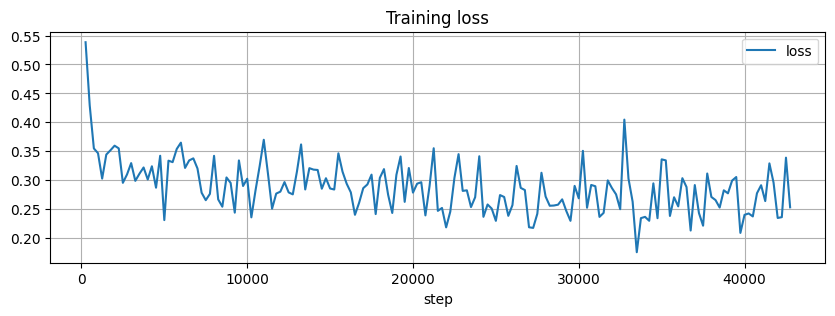

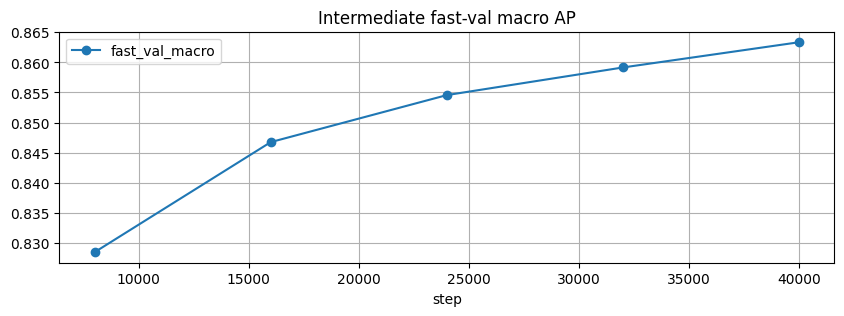

In [ ]:
# Preflight + обучение. Пути маскируются в notebook и train.log.
def gpu_memory_used():
    output = subprocess.check_output([
        "nvidia-smi", "--query-gpu=index,memory.used",
        "--format=csv,noheader,nounits",
    ], text=True)
    return {int(line.split(",")[0]): int(line.split(",")[1]) for line in output.splitlines()}

selected = [int(x) for x in GPU_IDS.split(",")]
used = gpu_memory_used()
print("selected physical GPUs:", selected, "| used MiB:", {i: used[i] for i in selected})
assert all(i in used for i in selected), "Выбранная GPU не найдена"

if RUN_TRAIN:
    busy = {i: used[i] for i in selected if used[i] > MAX_USED_MIB}
    if busy:
        raise RuntimeError(f"Выбранные GPU заняты: {busy}. Дождитесь освобождения; обучение не запущено.")
    if OUT.exists():
        raise FileExistsError(f"Run уже существует: ***/{RUN_ID}")
    OUT.mkdir(parents=True)
    (OUT / "run_config.json").write_text(json.dumps(CONFIG, ensure_ascii=False, indent=2))
    env = os.environ.copy()
    env.update(CUDA_VISIBLE_DEVICES=GPU_IDS,
               STAGE_A_ITEMS_PATH=str(DATA_DIR / "items.parquet"),
               STAGE_A_MATCHES_PATH=str(DATA_DIR / "matches_llm.parquet"),
               STAGE_A_OUT_DIR=str(OUT),
               STAGE_A_LOG_EVERY=str(LOG_EVERY),
               STAGE_A_EVAL_EVERY=str(EVAL_EVERY),
               STAGE_A_GLOBAL_BATCH="512")
    # Для одной GPU запускаем напрямую: без лишней NCCL-группы и barrier warning.
    if NPROC == 1:
        command = [sys.executable, str(TRAIN_SCRIPT)]
        print(f"$ CUDA_VISIBLE_DEVICES={GPU_IDS} python ***/train_user_bge_m3_320.py")
    else:
        command = [sys.executable, "-m", "torch.distributed.run",
                   "--nproc_per_node", str(NPROC), str(TRAIN_SCRIPT)]
        print(f"$ CUDA_VISIBLE_DEVICES={GPU_IDS} python -m torch.distributed.run --nproc_per_node={NPROC} ***/train_user_bge_m3_320.py")
    secrets = sorted({str(OUT), str(DATA_DIR), str(PROJECT_DIR), str(TRAIN_SCRIPT)}, key=len, reverse=True)
    with LOG.open("w", encoding="utf-8") as log:
        process = subprocess.Popen(command, cwd=PROJECT_DIR, env=env,
            stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
        assert process.stdout is not None
        for line in process.stdout:
            for secret in secrets: line = line.replace(secret, "***")
            print(line, end=""); log.write(line); log.flush()
        code = process.wait()
    assert code == 0, f"Ошибка обучения; см. ***/{RUN_ID}/train.log"
else:
    print("Dry run: поставьте RUN_TRAIN=True для обучения.")

# История доступна и после перезапуска kernel.
history_path = OUT / "training_history.jsonl"
if history_path.exists():
    history = pd.read_json(history_path, lines=True)
    print("Последние промежуточные значения:")
    display(history.tail(20))
    train_history = history[history.event == "train"]
    eval_history = history[history.event == "eval"]
    if not train_history.empty:
        train_history.plot(x="step", y="loss", figsize=(10, 3), grid=True, title="Training loss")
    if not eval_history.empty:
        eval_history.plot(x="step", y="fast_val_macro", marker="o", figsize=(10, 3),
                          grid=True, title="Intermediate fast-val macro AP")

In [ ]:
# Метрики только НОВОГО run. Старый reference автоматически не подставляется.
ACTIVE = OUT
metrics_path = ACTIVE / "metrics.json"
if not metrics_path.exists():
    print(f"Новый run ***/{RUN_ID} ещё не обучен — метрик и артефактов пока нет.")
else:
    print("new run:", f"***/{RUN_ID}")
    metrics = json.loads(metrics_path.read_text())
    display(pd.DataFrame([metrics]).T.rename(columns={0: "value"}))
    required = ["best.pt", "last.pt", "metrics.json", "export/config.json", "training_history.jsonl"]
    artifacts = pd.DataFrame([{
        "artifact": rel, "exists": (ACTIVE / rel).exists(),
        "size_MiB": round((ACTIVE / rel).stat().st_size / 1024**2, 2) if (ACTIVE / rel).exists() else None,
    } for rel in required])
    display(artifacts)
    assert artifacts["exists"].all()
    print("Следующий этап: используйте ***/best.pt как init для Stage-B.")

new run: ***/research_worker_s42_02


,value
model,deepvk/USER-bge-m3
max_len,320
epochs,2
swap,0.5
confidence_weighting,True
full_llm_holdout_macro,0.860026
best_fastval,0.863355
world_size,2


,artifact,exists,size_MiB
0,best.pt,True,1369.71
1,last.pt,True,1369.71
2,metrics.json,True,0.00
3,export/config.json,True,0.00
4,training_history.jsonl,True,0.02


Следующий этап: используйте ***/best.pt как init для Stage-B.
